# EKE as a function of physical depth

This notebook calculates horizontal EKE at each saved vertical level. The NetCDF `diag_levels` values are treated as **1-based model-level indices**. Physical cell-centre depths are reconstructed from the hard-coded `delR` array assigned to each case.

$$\mathrm{EKE}(z)=\frac{1}{2}\left\langle (u-\langle u\rangle_{x,y})^2+(v-\langle v\rangle_{x,y})^2\right\rangle_{x,y}.$$


In [15]:
from pathlib import Path
import json
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ============================================================
# SETTINGS
# ============================================================

NB_DIR = Path.cwd()
DATA_DIR = (NB_DIR / "../data/input").resolve()
RESULTS_DIR = (NB_DIR / "../results").resolve()

# Select the NetCDF files to compare.
CASE_FILES = {
    "Reference, V84 (FEB-1)": DATA_DIR / "run_feb1_spinup.nc",
    "V42-3000 meter (FEB-1)": DATA_DIR / "run_feb1_v42_d3000_spinup.nc",
    "V42-2000 meter (FEB-1)": DATA_DIR / "run_feb1_v42_d2000_spinup.nc",
}


# Corresponding run folders used for domain-characterization JSON files.
# The JSON is expected at:
# ../results/<case_name>/<case_name>_domain_characterization.json
CASE_NAME_BY_LABEL = {
    "Reference, V84 (FEB-1)": "run_feb1",
    "V42-3000 meter (FEB-1)": "run_feb1_v42_d3000_spinup",
    "V42-2000 meter (FEB-1)": "run_feb1_v42_d2000_spinup",
}

TIME_INDEX = 0
MAX_PLOT_DEPTH_M = None

# ============================================================
# VERTICAL DISCRETIZATIONS: delR [m]
# ============================================================

V84 = np.array([
    2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0,
    2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0,
    2.0, 2.0, 2.0, 2.0, 2.0, 2.2, 2.4, 2.6, 2.9, 3.1,
    3.4, 3.7, 4.0, 4.4, 4.8, 5.2, 5.7, 6.2, 6.8, 7.4,
    8.1, 8.8, 9.6, 10.5, 11.4, 12.5, 13.6, 14.8, 16.2, 17.6,
    19.2, 21.0, 22.9, 24.9, 27.2, 29.7, 32.4, 35.4, 38.6, 42.1,
    45.9, 50.0, 54.5, 59.4, 64.8, 70.6, 77.0, 84.0, 91.5, 99.7,
    108.7, 118.5, 129.1, 140.8, 153.5, 167.3, 182.4, 198.8, 216.7, 236.2,
    257.5, 280.7, 306.1, 328.5
], dtype=float)

V42_D4000 = np.array([
    *([2.0] * 25),
    2.200,
    3.282, 4.895, 7.301, 10.890,
    16.244, 24.230, 36.141, 53.908,
    80.410, 119.940, 178.903, 266.853,
    398.039, 593.717, 885.592, 1320.955
], dtype=float)

V42_D3000 = np.array([
    *([2.0] * 25),
    2.200,
    3.282, 4.781, 6.965, 10.146,
    14.779, 21.530, 31.363, 45.688,
    66.555, 96.952, 141.234, 205.740,
    299.708, 436.594, 636.001, 926.482
], dtype=float)

V42_D2000 = np.array([
    *([2.0] * 25),
    2.200,
    3.282, 4.628, 6.526, 9.203,
    12.977, 18.299, 25.803, 36.386,
    51.308, 72.351, 102.023, 143.865,
    202.867, 286.067, 403.389, 568.826
], dtype=float)

V42_D1500 = np.array([
    *([2.0] * 25),
    2.200,
    3.282, 4.520, 6.224, 8.572,
    11.805, 16.257, 22.388, 30.832,
    42.460, 58.474, 80.527, 110.897,
    152.722, 210.320, 289.642, 398.878
], dtype=float)


# The keys here must match CASE_FILES.
DELR_BY_CASE = {
    "Reference, V84 (FEB-1)": V84,
    "V42-3000 meter (FEB-1)": V42_D3000,
    "V42-2000 meter (FEB-1)": V42_D2000,
    "V42-1500 meter (FEB-1)": V42_D1500,
}


In [16]:
def layer_center_depths(delR):
    """Return positive-down MITgcm cell-centre depths [m]."""
    delR = np.asarray(delR, dtype=float)
    return np.cumsum(delR) - 0.5 * delR

def calculate_eke_profile(filepath, delR, time_index=0):
    """
    Calculate horizontal EKE as a function of physical depth.

    EKE is calculated at the vertical cell centres.
    Cell-top and cell-bottom depths are returned only for plotting.
    """
    filepath = Path(filepath)
    delR = np.asarray(delR, dtype=float)

    with xr.open_dataset(filepath, decode_times=False) as ds:
        u = ds["UVEL"]
        v = ds["VVEL"]

        depth_dim = next(
            dim for dim in u.dims
            if dim.startswith("Z") or "depth" in dim.lower()
        )

        # MITgcm diagnostic levels are 1-based indices
        if "diag_levels" in ds:
            level_indices = (
                np.rint(
                    np.asarray(
                        ds["diag_levels"].values,
                        dtype=float,
                    )
                ).astype(int)
                - 1
            )
        else:
            level_indices = np.arange(
                ds.sizes[depth_dim]
            )

        if (
            np.any(level_indices < 0)
            or np.any(level_indices >= len(delR))
        ):
            raise IndexError(
                f"{filepath.name}: diag_levels does not match "
                f"the supplied delR (Nr={len(delR)})."
            )

        # ========================================================
        # Physical vertical grid
        # ========================================================

        cell_bottom_all = np.cumsum(delR)

        cell_top_all = np.concatenate([
            [0.0],
            cell_bottom_all[:-1],
        ])

        cell_center_all = (
            cell_top_all
            + 0.5 * delR
        )

        # Physical depths for the levels contained in this NetCDF
        z = cell_center_all[level_indices]
        cell_top = cell_top_all[level_indices]
        cell_bottom = cell_bottom_all[level_indices]

        # ========================================================
        # Read velocity
        # ========================================================

        time_dim = (
            "T"
            if "T" in u.dims
            else "time"
        )

        u_raw = u.isel({
            time_dim: time_index
        }).values

        v_raw = v.isel({
            time_dim: time_index
        }).values

    # ============================================================
    # MITgcm C-grid -> tracer-cell centres
    # ============================================================

    u_c = 0.5 * (
        u_raw[..., :, :-1]
        + u_raw[..., :, 1:]
    )

    v_c = 0.5 * (
        v_raw[..., :-1, :]
        + v_raw[..., 1:, :]
    )

    ny = min(
        u_c.shape[-2],
        v_c.shape[-2],
    )

    nx = min(
        u_c.shape[-1],
        v_c.shape[-1],
    )

    u_c = np.asarray(
        u_c[..., :ny, :nx],
        dtype=float,
    )

    v_c = np.asarray(
        v_c[..., :ny, :nx],
        dtype=float,
    )

    # ============================================================
    # EKE
    # ============================================================

    u_prime = (
        u_c
        - np.nanmean(
            u_c,
            axis=(-2, -1),
            keepdims=True,
        )
    )

    v_prime = (
        v_c
        - np.nanmean(
            v_c,
            axis=(-2, -1),
            keepdims=True,
        )
    )

    eke = 0.5 * np.nanmean(
        u_prime**2 + v_prime**2,
        axis=(-2, -1),
    )

    # Sort shallow -> deep
    order = np.argsort(z)

    z = z[order]
    cell_top = cell_top[order]
    cell_bottom = cell_bottom[order]
    level_indices = level_indices[order]
    eke = eke[order]

    if (
        np.isfinite(eke[0])
        and eke[0] != 0
    ):
        eke_norm = eke / eke[0]
    else:
        eke_norm = np.full_like(
            eke,
            np.nan,
        )

    return {
        "depth_m": z,
        "cell_top": cell_top,
        "cell_bottom": cell_bottom,
        "level_indices": level_indices,
        "eke_m2_s2": eke,
        "eke_normalized": eke_norm,
        "total_depth_m": float(np.sum(delR)),
    }

profiles = {}

for label, filepath in CASE_FILES.items():

    if label not in DELR_BY_CASE:
        raise KeyError(
            f"No delR assigned for case '{label}'."
        )

    if not Path(filepath).exists():
        raise FileNotFoundError(filepath)

    profiles[label] = calculate_eke_profile(
        filepath,
        DELR_BY_CASE[label],
        time_index=TIME_INDEX,
    )

    p = profiles[label]

    print(
        f"{label}: "
        f"{len(p['depth_m'])} saved levels, "
        f"centres {p['depth_m'][0]:.2f}-"
        f"{p['depth_m'][-1]:.2f} m, "
        f"bottom = {p['total_depth_m']:.2f} m"
    )

Reference, V84 (FEB-1): 61 saved levels, centres 1.00-554.25 m, bottom = 4053.50 m
V42-3000 meter (FEB-1): 42 saved levels, centres 1.00-2536.76 m, bottom = 3000.00 m
V42-2000 meter (FEB-1): 42 saved levels, centres 1.00-1715.59 m, bottom = 2000.00 m


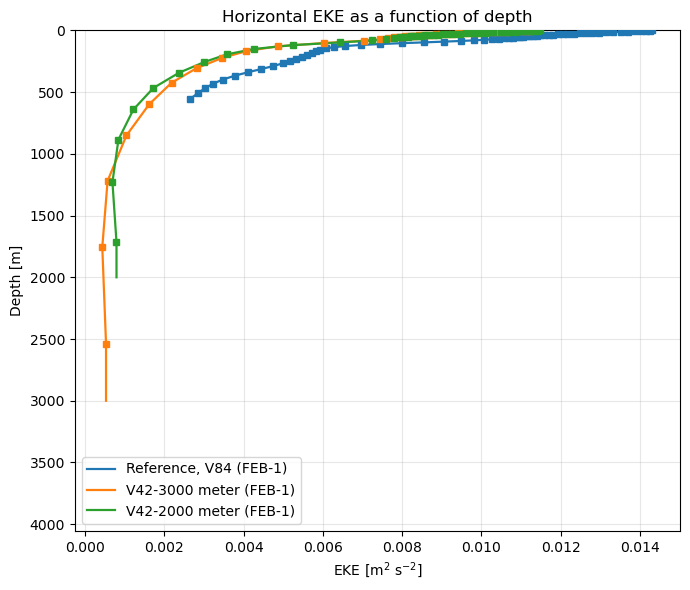

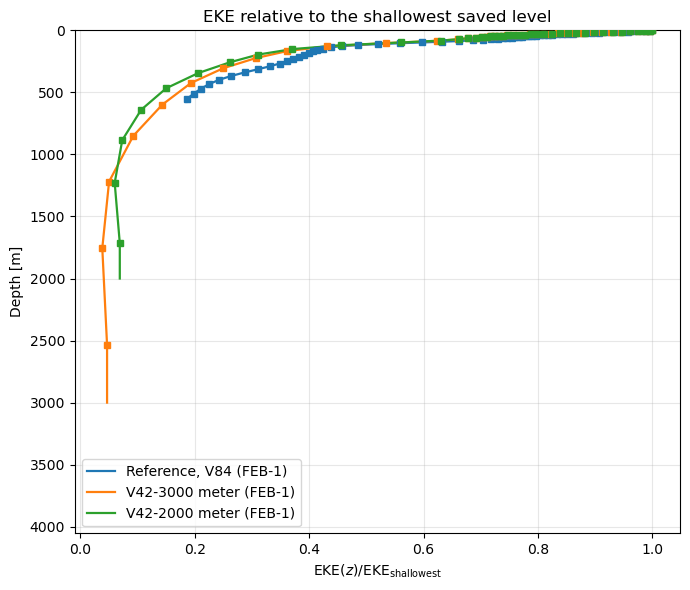

In [17]:
def plot_vertical_cell_profile(
    ax,
    values,
    profile,
    label,
):
    """
    Plot a smooth profile through the cell-centre EKE values.

    Squares mark the actual cell-centre locations where EKE is calculated.
    The line is extended to the top of the shallowest saved cell and
    bottom of the deepest saved cell using the corresponding EKE value.
    """

    z_center = np.asarray(profile["depth_m"])
    z_top = np.asarray(profile["cell_top"])
    z_bottom = np.asarray(profile["cell_bottom"])
    values = np.asarray(values)

    # Extend the profile to the physical boundaries of the
    # shallowest and deepest saved cells.
    z_line = np.concatenate([
        [z_top[0]],
        z_center,
        [z_bottom[-1]],
    ])

    values_line = np.concatenate([
        [values[0]],
        values,
        [values[-1]],
    ])

    # Smooth connecting line
    line, = ax.plot(
        values_line,
        z_line,
        linewidth=1.6,
        label=label,
        zorder=2,
    )

    # Actual EKE calculation locations
    ax.plot(
        values,
        z_center,
        linestyle="none",
        marker="s",
        ms=4,
        color=line.get_color(),
        zorder=3,
    )

    return line


# Deepest physical model bottom among all cases
MAX_TOTAL_DEPTH = max(
    p["total_depth_m"]
    for p in profiles.values()
)


# ============================================================
# ABSOLUTE EKE PROFILE
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))

for label, p in profiles.items():

    plot_vertical_cell_profile(
        ax,
        p["eke_m2_s2"],
        p,
        label,
    )

ax.set_xlabel(
    r"EKE [m$^2$ s$^{-2}$]"
)

ax.set_ylabel(
    "Depth [m]"
)

ax.set_title(
    "Horizontal EKE as a function of depth"
)

ax.set_ylim(
    MAX_TOTAL_DEPTH,
    0,
)

ax.grid(
    True,
    alpha=0.3,
)

if MAX_PLOT_DEPTH_M is not None:
    ax.set_ylim(
        MAX_PLOT_DEPTH_M,
        0,
    )

if len(profiles) > 1:
    ax.legend()

plt.tight_layout()
plt.show()


# ============================================================
# NORMALIZED EKE PROFILE
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))

for label, p in profiles.items():

    plot_vertical_cell_profile(
        ax,
        p["eke_normalized"],
        p,
        label,
    )

ax.set_xlabel(
    r"EKE$(z)$/EKE$_{\mathrm{shallowest}}$"
)

ax.set_ylabel(
    "Depth [m]"
)

ax.set_title(
    "EKE relative to the shallowest saved level"
)

ax.set_ylim(
    MAX_TOTAL_DEPTH,
    0,
)

ax.grid(
    True,
    alpha=0.3,
)

if MAX_PLOT_DEPTH_M is not None:
    ax.set_ylim(
        MAX_PLOT_DEPTH_M,
        0,
    )

if len(profiles) > 1:
    ax.legend()

plt.tight_layout()
plt.show()


Median MLD values used:
Reference, V84 (FEB-1): 32.19 m
V42-3000 meter (FEB-1): 29.86 m
V42-2000 meter (FEB-1): 29.85 m


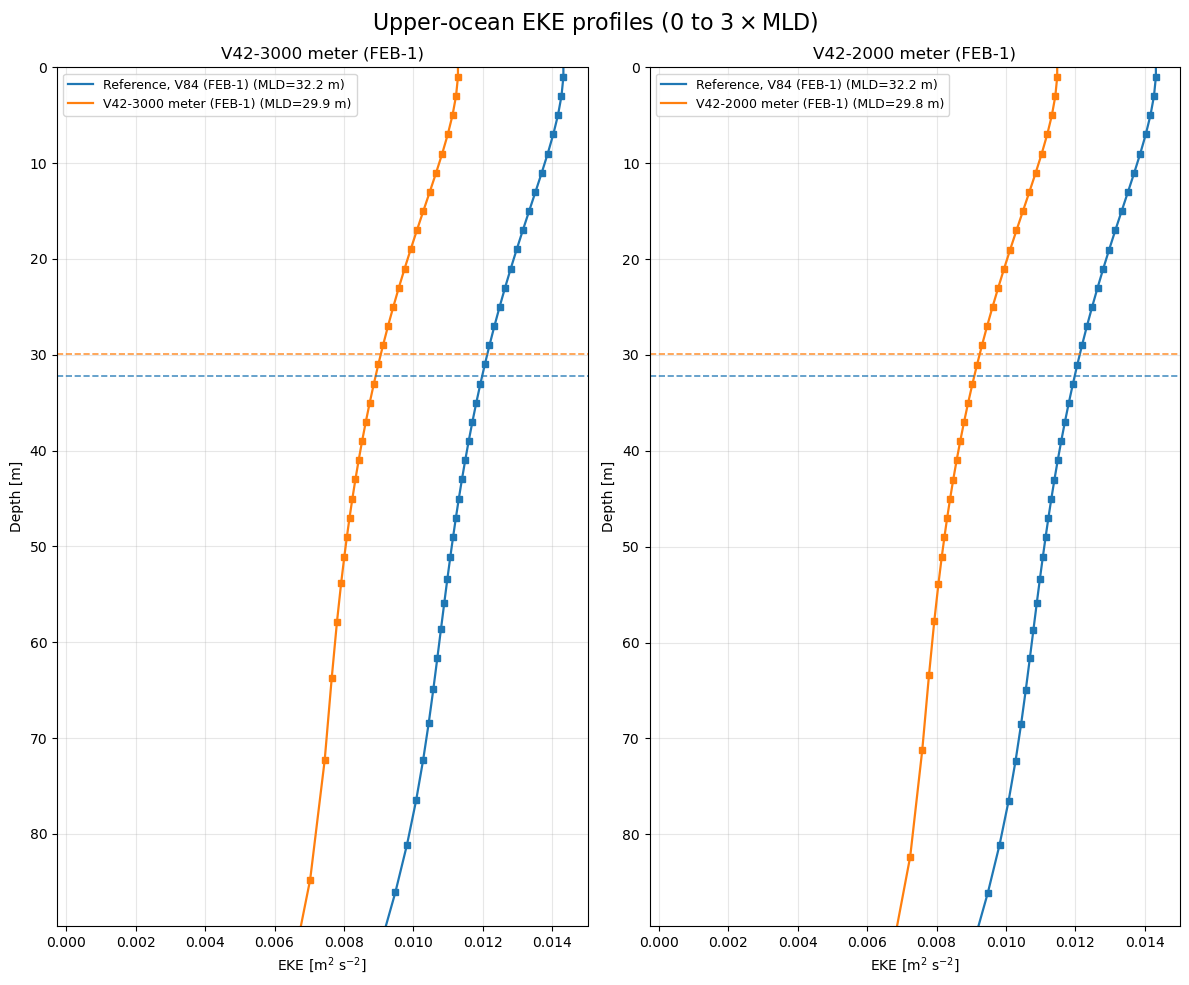

In [19]:
# ============================================================
# UPPER-OCEAN EKE COMPARISON: 0 TO 3 x MLD
# ============================================================

def read_mld_median(case_name):
    """
    Read mld_median_m from the corresponding
    domain_characterization JSON file.
    """
    json_file = (
        RESULTS_DIR
        / case_name
        / f"{case_name}_domain_characterization.json"
    )

    if not json_file.exists():
        raise FileNotFoundError(
            f"Domain-characterization JSON not found:\n{json_file}"
        )

    with json_file.open("r", encoding="utf-8") as f:
        data = json.load(f)

    if "mld_median_m" not in data:
        raise KeyError(
            f"'mld_median_m' not found in {json_file}"
        )

    return float(data["mld_median_m"])


# Read one MLD value for every plotted case.
MLD_BY_CASE = {
    label: read_mld_median(CASE_NAME_BY_LABEL[label])
    for label in CASE_FILES
}

print("\nMedian MLD values used:")
for label, mld in MLD_BY_CASE.items():
    print(f"{label:>18s}: {mld:.2f} m")


# Compare each reduced-depth case directly with the V84 benchmark.
REFERENCE_LABEL = "Reference, V84 (FEB-1)"

comparison_labels = [
    label
    for label in CASE_FILES
    if label != REFERENCE_LABEL
]

ncols = 2
nrows = int(np.ceil(len(comparison_labels) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(12, 10),
    sharex=True,
    sharey=False,
)

axes = np.atleast_1d(axes).ravel()

reference_profile = profiles[REFERENCE_LABEL]
reference_mld = MLD_BY_CASE[REFERENCE_LABEL]

for ax, label in zip(axes, comparison_labels):

    profile = profiles[label]
    case_mld = MLD_BY_CASE[label]

    # Zoom to three times the median MLD of this run.
    zoom_depth = 3.0 * case_mld

    ref_line = plot_vertical_cell_profile(
        ax,
        reference_profile["eke_m2_s2"],
        reference_profile,
        f"{REFERENCE_LABEL} (MLD={reference_mld:.1f} m)",
    )

    case_line = plot_vertical_cell_profile(
        ax,
        profile["eke_m2_s2"],
        profile,
        f"{label} (MLD={case_mld:.1f} m)",
    )

    # Show the median MLD of both simulations.
    ax.axhline(
        reference_mld,
        color=ref_line.get_color(),
        linestyle="--",
        linewidth=1.2,
        alpha=0.8,
    )

    ax.axhline(
        case_mld,
        color=case_line.get_color(),
        linestyle="--",
        linewidth=1.2,
        alpha=0.8,
    )

    ax.set_ylim(zoom_depth, 0)
    ax.set_title(label)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

    ax.set_xlabel(r"EKE [m$^2$ s$^{-2}$]")
    ax.set_ylabel("Depth [m]")


# Hide unused axes if the number of cases changes.
for ax in axes[len(comparison_labels):]:
    ax.set_visible(False)


fig.suptitle(
    r"Upper-ocean EKE profiles ($0$ to $3\times$MLD)",
    fontsize=16,
)

plt.tight_layout()
plt.show()
